In [ ]:
import os
import cv2
import shutil
import random
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras.preprocessing.image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, Flatten, BatchNormalization, LeakyReLU, GlobalAveragePooling2D, Conv2D, MaxPool2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, Nadam, RMSprop
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Set the path to the dataset
dataset_path = "/content/drive/MyDrive/dataset/Train & Val"
os.listdir(dataset_path)

Mounted at /content/drive


['Grade 3', 'Grade 2', 'Grade 1', 'processed']

In [ ]:
print('Grade 1 :',len(os.listdir("/content/drive/MyDrive/dataset/Train & Val/Grade 1")))
print('Grade 2 :',len(os.listdir("/content/drive/MyDrive/dataset/Train & Val/Grade 2")))
print('Grade 3 :',len(os.listdir("/content/drive/MyDrive/dataset/Train & Val/Grade 3")))

Grade 1 : 1000
Grade 2 : 1000
Grade 3 : 1000


In [ ]:
# Load the dataset
data = []
labels = []

# Iterate through the dataset path and load the images
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)

        # Check if the image file exists
        if os.path.isfile(image_path):
            # Read the image file
            image = cv2.imread(image_path)

            # Check if the image reading was successful
            if image is not None:
                # Resize the image
                image = cv2.resize(image, (150, 150))
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                data.append(image)
                labels.append(category)

# Convert data and labels to numpy arrays
data = np.array(data)
labels = np.array(labels)


In [ ]:
# Perform label encoding
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

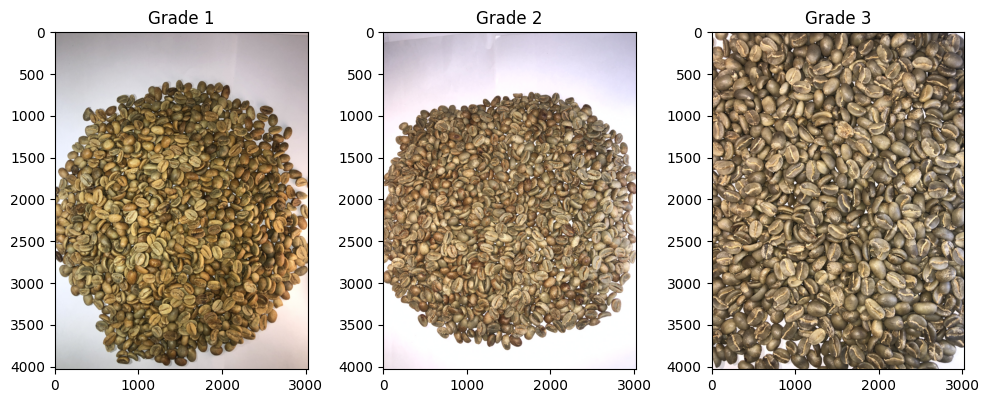

In [ ]:
# Get a list of images in each grade folder
grade1_images = os.listdir(os.path.join(dataset_path, "Grade 1"))
grade2_images = os.listdir(os.path.join(dataset_path, "Grade 2"))
grade3_images = os.listdir(os.path.join(dataset_path, "Grade 3"))

# Choose a random sample from each grade
sample_grade1 = random.choice(grade1_images)
sample_grade2 = random.choice(grade2_images)
sample_grade3 = random.choice(grade3_images)

# Load and display the sample images
sample1_path = os.path.join(dataset_path, "Grade 1", sample_grade1)
sample2_path = os.path.join(dataset_path, "Grade 2", sample_grade2)
sample3_path = os.path.join(dataset_path, "Grade 3", sample_grade3)

sample1_img = cv2.imread(sample1_path)
sample2_img = cv2.imread(sample2_path)
sample3_img = cv2.imread(sample3_path)

# Convert BGR to RGB
sample1_img = cv2.cvtColor(sample1_img, cv2.COLOR_BGR2RGB)
sample2_img = cv2.cvtColor(sample2_img, cv2.COLOR_BGR2RGB)
sample3_img = cv2.cvtColor(sample3_img, cv2.COLOR_BGR2RGB)

# Plot the images
plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(sample1_img)
plt.title("Grade 1")

plt.subplot(1, 3, 2)
plt.imshow(sample2_img)
plt.title("Grade 2")

plt.subplot(1, 3, 3)
plt.imshow(sample3_img)
plt.title("Grade 3")

plt.tight_layout()
plt.show()

In [ ]:
# Perform data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  # Random rotation
    width_shift_range=0.1,  # Random horizontal shift
    height_shift_range=0.1,  # Random vertical shift
    shear_range=0.1,  # Shear transformation
    zoom_range=0.1,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Split the dataset into train and validation sets
train_data, val_data, train_labels, val_labels = train_test_split(
    data, labels, test_size=0.2, stratify=labels, random_state=42, shuffle=True
)

In [ ]:
# Apply data augmentation to the training set
train_generator = train_datagen.flow(train_data, train_labels, batch_size=32)

# Apply data augmentation to the validation set
val_generator = val_datagen .flow(val_data, val_labels, batch_size=32)

In [ ]:
# Get the class names
class_names = label_encoder.classes_

# Display the class names
print("Class Names:", class_names)

Class Names: ['Grade 1' 'Grade 2' 'Grade 3']


In [ ]:
# Normalize the image data
train_data = train_data.astype('float32') / 255.0
val_data = val_data.astype('float32') / 255.0

# Print the shape of each dataset
print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)
print("Train labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)

Train data shape: (2400, 150, 150, 3)
Validation data shape: (600, 150, 150, 3)
Train labels shape: (2400,)
Validation labels shape: (600,)


In [ ]:
print('Train :', len(train_data))
print('Validation :', len(val_data))

Train : 2400
Validation : 600


**MOBILENET**

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Load the MobileNetV2 model without the top classifier
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top of the base model
mobilenetv2_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# Compile the model
mobilenetv2_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
mobilenetv2_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                 387       
                                                                 
Total params: 2,422,339
Trainable params: 164,355
Non-tr

In [ ]:
# Train the model
history_v2 = mobilenetv2_model.fit(train_data, train_labels,
                    epochs=15,
                    batch_size=32,
                    validation_data=(val_data, val_labels))

Epoch 1/15
75/75 [==============================] - 64s 778ms/step - loss: 0.6963 - accuracy: 0.7129 - val_loss: 0.3001 - val_accuracy: 0.9333
Epoch 2/15
75/75 [==============================] - 68s 910ms/step - loss: 0.2507 - accuracy: 0.9379 - val_loss: 0.1455 - val_accuracy: 0.9700
Epoch 3/15
75/75 [==============================] - 66s 887ms/step - loss: 0.1349 - accuracy: 0.9767 - val_loss: 0.0858 - val_accuracy: 0.9950
Epoch 4/15
75/75 [==============================] - 59s 792ms/step - loss: 0.0935 - accuracy: 0.9854 - val_loss: 0.0606 - val_accuracy: 0.9950
Epoch 5/15
75/75 [==============================] - 71s 956ms/step - loss: 0.0669 - accuracy: 0.9900 - val_loss: 0.0465 - val_accuracy: 0.9950
Epoch 6/15
75/75 [==============================] - 57s 761ms/step - loss: 0.0500 - accuracy: 0.9929 - val_loss: 0.0367 - val_accuracy: 0.9950
Epoch 7/15
75/75 [==============================] - 68s 909ms/step - loss: 0.0419 - accuracy: 0.9950 - val_loss: 0.0297 - val_accuracy: 0.9950

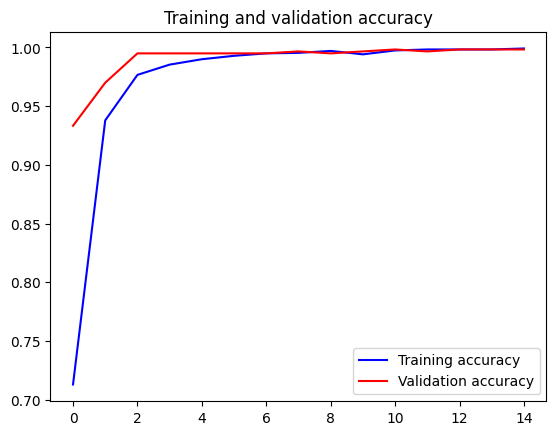

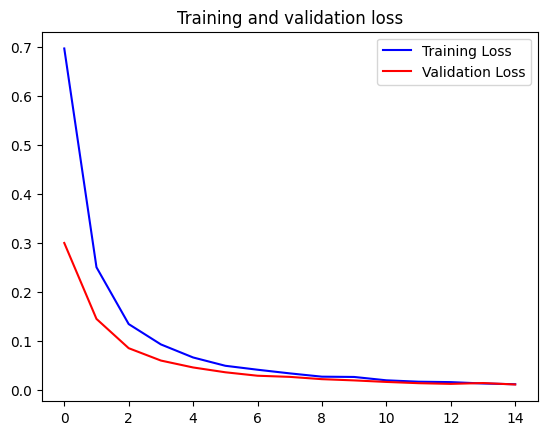

In [ ]:
import matplotlib.pyplot as plt

acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# Get the train accuracy
train_loss, train_accuracy = mobilenetv2_model.evaluate(train_data, train_labels)
print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

# Get the val accuracy
val_loss, val_accuracy = mobilenetv2_model.evaluate(val_data, val_labels)
print("Val Loss:", val_loss)
print("Val Accuracy:", val_accuracy)

75/75 [==============================] - 48s 636ms/step - loss: 0.0075 - accuracy: 1.0000
Train Loss: 0.007462589535862207
Train Accuracy: 1.0
19/19 [==============================] - 10s 519ms/step - loss: 0.0119 - accuracy: 0.9983
Val Loss: 0.011882811784744263
Val Accuracy: 0.9983333349227905


In [ ]:
mobilenetv2_model.save('mobilenetv2_model.h5')
mobilenetv2_model.save('mobilenetv2_model')
!zip -r 'mobilenetv2_model.zip' 'mobilenetv2_model'

  adding: mobilenetv2_model/ (stored 0%)
  adding: mobilenetv2_model/saved_model.pb (deflated 91%)
  adding: mobilenetv2_model/variables/ (stored 0%)
  adding: mobilenetv2_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: mobilenetv2_model/variables/variables.index (deflated 76%)
  adding: mobilenetv2_model/assets/ (stored 0%)
  adding: mobilenetv2_model/fingerprint.pb (stored 0%)
  adding: mobilenetv2_model/keras_metadata.pb (deflated 96%)


In [ ]:
import pathlib

converter = tf.lite.TFLiteConverter.from_saved_model('mobilenetv2_model')

# Set the optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()

tflite_model_file = pathlib.Path('./mobilenetv2_model.tflite')
tflite_model_file.write_bytes(tflite_model)

2674736

In [ ]:
import os

# Set the path to the test dataset folder
test_dataset_path = "/content/drive/MyDrive/dataset/Test"

# Load the test dataset
test_data = []
test_labels = []

# Iterate through the test dataset path and load the images
for category in os.listdir(test_dataset_path):
    category_path = os.path.join(test_dataset_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (150, 150))
        test_data.append(image)
        test_labels.append(category)

# Convert test_data and test_labels to numpy arrays
test_data = np.array(test_data)
test_labels = np.array(test_labels)

# Perform label encoding for test_labels
test_labels = label_encoder.transform(test_labels)

# Apply data normalization to test_data
test_data = test_data.astype('float32') / 255.0

# Create a dictionary to store the accuracy for each folder
folder_accuracy = {}

# Iterate over the folders in the test dataset
for folder in os.listdir(test_dataset_path):
    folder_path = os.path.join(test_dataset_path, folder)

    # Filter the test data and labels for the current folder
    folder_test_data = test_data[test_labels == label_encoder.transform([folder])[0]]
    folder_test_labels = test_labels[test_labels == label_encoder.transform([folder])[0]]

    # Evaluate the model on the current folder's test data
    folder_loss, folder_accuracy[folder] = mobilenetv2_model.evaluate(folder_test_data, folder_test_labels, verbose=0)

# Print the accuracy for each folder
for folder, accuracy in folder_accuracy.items():
    print(f"Accuracy for folder {folder}: {accuracy}")


Accuracy for folder Grade 3: 0.9399999976158142
Accuracy for folder Grade 2: 0.9800000190734863
Accuracy for folder Grade 1: 0.9800000190734863


In [ ]:
# Get the test accuracy
test_loss, test_accuracy = mobilenetv2_model.evaluate(test_data, test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 [==============================] - 5s 513ms/step - loss: 0.0733 - accuracy: 0.9667
Test Loss: 0.07333065569400787
Test Accuracy: 0.9666666388511658


In [ ]:
# Make predictions on the test data
test_predictions = mobilenetv2_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Compare the predicted classes with the true classes
for i in range(len(test_labels)):
    print("True Label: ", label_encoder.inverse_transform([test_labels[i]]))
    print("Predicted Label: ", predicted_classes[i])
    print("------------------------------------")

10/10 [==============================] - 6s 476ms/step
True Label:  ['Grade 3']
Predicted Label:  Grade 2
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 2
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
--------------

10/10 [==============================] - 6s 595ms/step


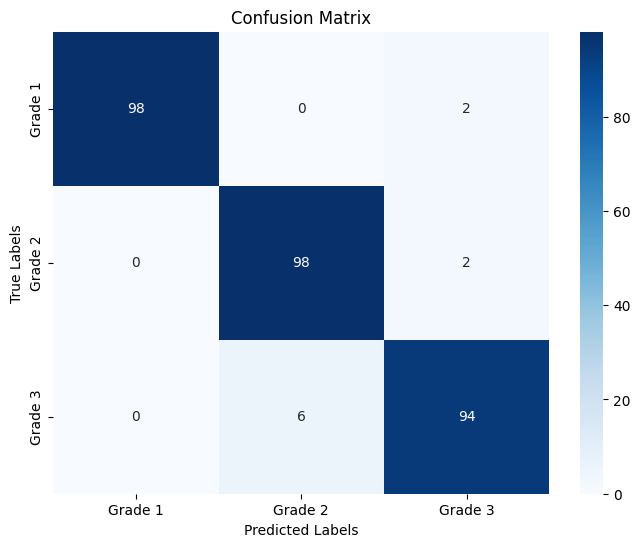

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Generate predictions on the test set
test_predictions = mobilenetv2_model.predict(test_data)

# Convert the predicted probabilities to class labels
test_predicted_labels = np.argmax(test_predictions, axis=1)

# Create a confusion matrix
cm = confusion_matrix(test_labels, test_predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

10/10 [==============================] - 6s 532ms/step


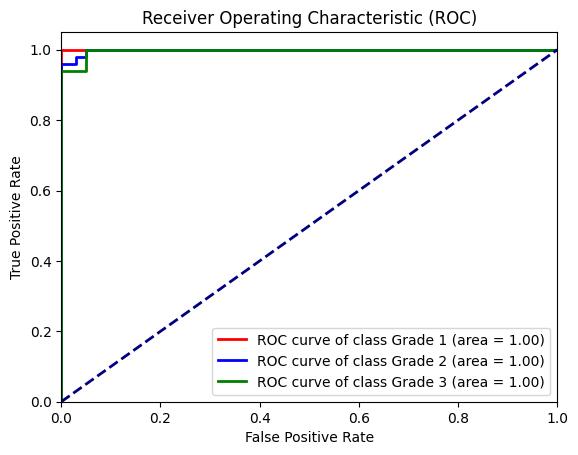

Macro-average ROC AUC: 0.9984666666666667


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
binary_labels = label_binarize(test_labels, classes=np.arange(len(class_names)))

# Compute the predicted probabilities for each class
class_probabilities = mobilenetv2_model.predict(test_data)

# Compute the macro-average ROC AUC score
roc_auc = roc_auc_score(binary_labels, class_probabilities, average='macro')

# Plot the ROC curve for each class
plt.figure()
lw = 2
colors = ['red', 'blue', 'green']  # Add more colors if there are more classes
for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(binary_labels[:, i], class_probabilities[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc_class))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print the macro-average ROC AUC score
print("Macro-average ROC AUC:", roc_auc)

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test data
test_predictions = mobilenetv2_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Generate the classification report
report = classification_report(test_labels, predicted_labels, target_names=class_names)

# Print the classification report
print("Classification Report:")
print(report)

10/10 [==============================] - 7s 708ms/step
Classification Report:
              precision    recall  f1-score   support

     Grade 1       1.00      0.98      0.99       100
     Grade 2       0.94      0.98      0.96       100
     Grade 3       0.96      0.94      0.95       100

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



**RESTNET**

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
restnet_v1 = "https://tfhub.dev/google/imagenet/resnet_v1_50/classification/5"
restnet_v1_layers = hub.KerasLayer(restnet_v1, input_shape=(150,150,3))
restnet_v1_layers.trainable = False

restnet_v1_model = tf.keras.Sequential([
    restnet_v1_layers,
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])

In [ ]:
restnet_v1_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
restnet_v1_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1001)              25612201  
                                                                 
 dropout_1 (Dropout)         (None, 1001)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               256512    
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 3)                 195       
                                                                 
Total params: 25,910,060
Trainable params: 297,859
Non

In [ ]:
hist = restnet_v1_model.fit(train_data, train_labels,
                            epochs=15,
                            batch_size=32,
                            validation_data=(val_data, val_labels)
                            )

Epoch 1/15
75/75 [==============================] - 276s 4s/step - loss: 0.0611 - accuracy: 0.9796 - val_loss: 0.0229 - val_accuracy: 0.9967
Epoch 2/15
75/75 [==============================] - 269s 4s/step - loss: 0.0457 - accuracy: 0.9867 - val_loss: 0.0198 - val_accuracy: 0.9950
Epoch 3/15
75/75 [==============================] - 283s 4s/step - loss: 0.0351 - accuracy: 0.9883 - val_loss: 0.0216 - val_accuracy: 0.9967
Epoch 4/15
75/75 [==============================] - 276s 4s/step - loss: 0.0431 - accuracy: 0.9837 - val_loss: 0.0194 - val_accuracy: 0.9967
Epoch 5/15
75/75 [==============================] - 269s 4s/step - loss: 0.0238 - accuracy: 0.9929 - val_loss: 0.0191 - val_accuracy: 0.9967
Epoch 6/15
75/75 [==============================] - 269s 4s/step - loss: 0.0305 - accuracy: 0.9892 - val_loss: 0.0175 - val_accuracy: 0.9983
Epoch 7/15
75/75 [==============================] - 269s 4s/step - loss: 0.0231 - accuracy: 0.9929 - val_loss: 0.0146 - val_accuracy: 0.9983
Epoch 8/15
75

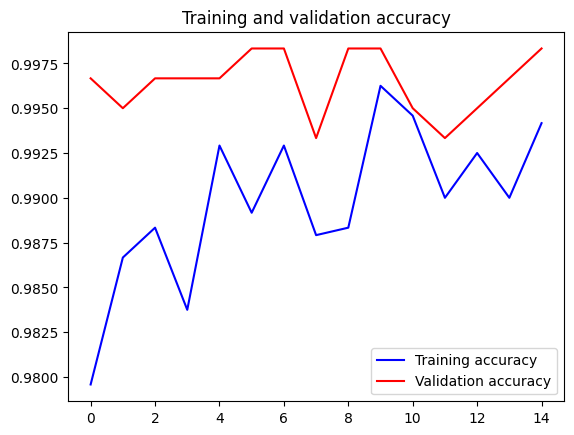

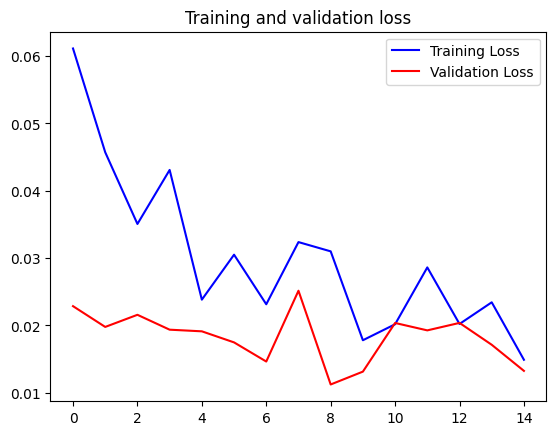

In [ ]:
import matplotlib.pyplot as plt

acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# Get the train accuracy
train_loss, train_accuracy = restnet_v1_model.evaluate(train_data, train_labels)
print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

# Get the val accuracy
val_loss, val_accuracy = restnet_v1_model.evaluate(val_data, val_labels)
print("Val Loss:", val_loss)
print("Val Accuracy:", val_accuracy)

75/75 [==============================] - 185s 2s/step - loss: 0.0023 - accuracy: 1.0000
Train Loss: 0.002258257707580924
Train Accuracy: 1.0
19/19 [==============================] - 46s 2s/step - loss: 0.0133 - accuracy: 0.9983
Val Loss: 0.013253085315227509
Val Accuracy: 0.9983333349227905


In [ ]:
restnet_v1_model.save('restnet_v1_model.h5')
restnet_v1_model.save('restnet_v1_model')
!zip -r 'restnet_v1_model.zip' 'restnet_v1_model'

  adding: restnet_v1_model/ (stored 0%)
  adding: restnet_v1_model/saved_model.pb (deflated 93%)
  adding: restnet_v1_model/variables/ (stored 0%)
  adding: restnet_v1_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: restnet_v1_model/variables/variables.index (deflated 80%)
  adding: restnet_v1_model/assets/ (stored 0%)
  adding: restnet_v1_model/fingerprint.pb (stored 0%)
  adding: restnet_v1_model/keras_metadata.pb (deflated 88%)


In [ ]:
import pathlib

converter = tf.lite.TFLiteConverter.from_saved_model('restnet_v1_model')

# Set the optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()

tflite_model_file = pathlib.Path('./restnet_v1_model.tflite')
tflite_model_file.write_bytes(tflite_model)

26315416

In [ ]:
import os

# Set the path to the test dataset folder
test_dataset_path = "/content/drive/MyDrive/dataset/Test"

# Load the test dataset
test_data = []
test_labels = []

# Iterate through the test dataset path and load the images
for category in os.listdir(test_dataset_path):
    category_path = os.path.join(test_dataset_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (150, 150))
        test_data.append(image)
        test_labels.append(category)

# Convert test_data and test_labels to numpy arrays
test_data = np.array(test_data)
test_labels = np.array(test_labels)

# Perform label encoding for test_labels
test_labels = label_encoder.transform(test_labels)

# Apply data normalization to test_data
test_data = test_data.astype('float32') / 255.0

# Create a dictionary to store the accuracy for each folder
folder_accuracy = {}

# Iterate over the folders in the test dataset
for folder in os.listdir(test_dataset_path):
    folder_path = os.path.join(test_dataset_path, folder)

    # Filter the test data and labels for the current folder
    folder_test_data = test_data[test_labels == label_encoder.transform([folder])[0]]
    folder_test_labels = test_labels[test_labels == label_encoder.transform([folder])[0]]

    # Evaluate the model on the current folder's test data
    folder_loss, folder_accuracy[folder] = restnet_v1_model.evaluate(folder_test_data, folder_test_labels, verbose=0)

# Print the accuracy for each folder
for folder, accuracy in folder_accuracy.items():
    print(f"Accuracy for folder {folder}: {accuracy}")

Accuracy for folder Grade 3: 1.0
Accuracy for folder Grade 2: 1.0
Accuracy for folder Grade 1: 0.9399999976158142


In [ ]:
# Make predictions on the test data
test_predictions = restnet_v1_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Compare the predicted classes with the true classes
for i in range(len(test_labels)):
    print("True Label: ", label_encoder.inverse_transform([test_labels[i]]))
    print("Predicted Label: ", predicted_classes[i])
    print("------------------------------------")

10/10 [==============================] - 25s 2s/step
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
------------------------------------
True Label:  ['Grade 3']
Predicted Label:  Grade 3
----------------

10/10 [==============================] - 24s 2s/step


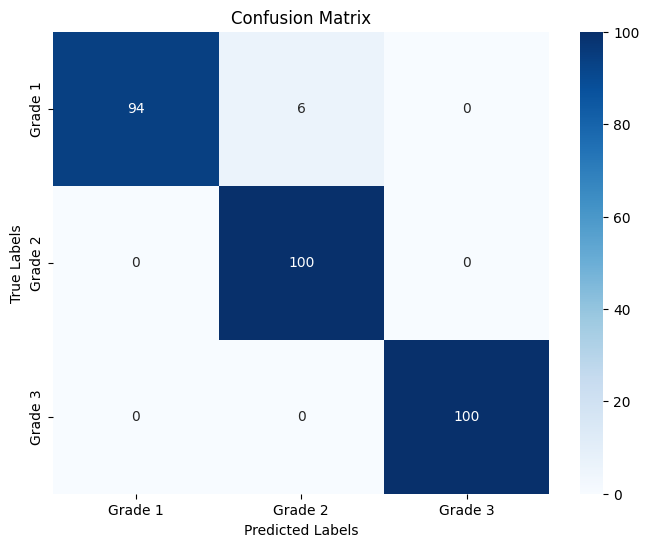

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Generate predictions on the test set
test_predictions = restnet_v1_model.predict(test_data)

# Convert the predicted probabilities to class labels
test_predicted_labels = np.argmax(test_predictions, axis=1)

# Create a confusion matrix
cm = confusion_matrix(test_labels, test_predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

10/10 [==============================] - 22s 2s/step


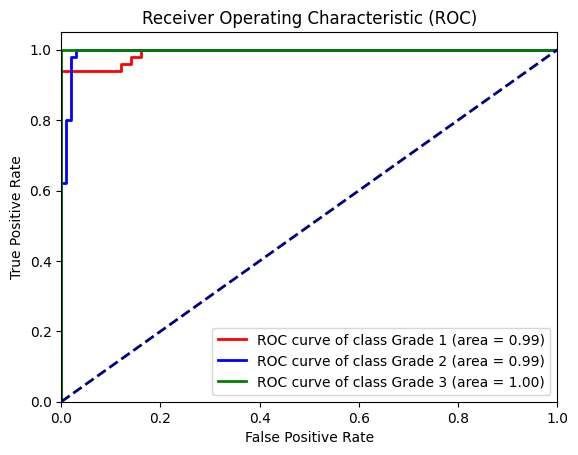

Macro-average ROC AUC: 0.9952


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
binary_labels = label_binarize(test_labels, classes=np.arange(len(class_names)))

# Compute the predicted probabilities for each class
class_probabilities = restnet_v1_model.predict(test_data)

# Compute the macro-average ROC AUC score
roc_auc = roc_auc_score(binary_labels, class_probabilities, average='macro')

# Plot the ROC curve for each class
plt.figure()
lw = 2
colors = ['red', 'blue', 'green']  # Add more colors if there are more classes
for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(binary_labels[:, i], class_probabilities[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc_class))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print the macro-average ROC AUC score
print("Macro-average ROC AUC:", roc_auc)

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test data
test_predictions = restnet_v1_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Generate the classification report
report = classification_report(test_labels, predicted_labels, target_names=class_names)

# Print the classification report
print("Classification Report:")
print(report)

10/10 [==============================] - 22s 2s/step
Classification Report:
              precision    recall  f1-score   support

     Grade 1       1.00      0.94      0.97       100
     Grade 2       0.94      1.00      0.97       100
     Grade 3       1.00      1.00      1.00       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
# Get the test accuracy
test_loss, test_accuracy = restnet_v1_model.evaluate(test_data, test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 [==============================] - 22s 2s/step - loss: 0.1935 - accuracy: 0.9800
Test Loss: 0.19351962208747864
Test Accuracy: 0.9800000190734863


**EfficientNetV2**

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0

In [ ]:
# Define the EfficientNetV2 model
EfficientNetV2_layer = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
EfficientNetV2_model = Sequential([
    EfficientNetV2_layer,
    GlobalAveragePooling2D(),
    Dense(3, activation='softmax')
])

24274472/24274472 [==============================] - 0s 0us/step


In [ ]:
# Compile the model
EfficientNetV2_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
EfficientNetV2_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Function  (None, 5, 5, 1280)       5919312   
 al)                                                             
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 3)                 3843      
                                                                 
Total params: 5,923,155
Trainable params: 5,862,547
Non-trainable params: 60,608
_________________________________________________________________


In [ ]:
history_v3 = EfficientNetV2_model.fit(train_data, train_labels,
                            epochs=15,
                            batch_size=32,
                            validation_data=(val_data, val_labels)
                            )

Epoch 1/15
75/75 [==============================] - 341s 5s/step - loss: 0.0054 - accuracy: 0.9987 - val_loss: 5.0111e-04 - val_accuracy: 1.0000
Epoch 2/15
75/75 [==============================] - 335s 4s/step - loss: 9.6916e-04 - accuracy: 1.0000 - val_loss: 0.0068 - val_accuracy: 0.9967
Epoch 3/15
75/75 [==============================] - 334s 4s/step - loss: 6.7492e-04 - accuracy: 1.0000 - val_loss: 0.0064 - val_accuracy: 0.9983
Epoch 4/15
75/75 [==============================] - 333s 4s/step - loss: 3.7146e-04 - accuracy: 1.0000 - val_loss: 0.0024 - val_accuracy: 0.9983
Epoch 5/15
75/75 [==============================] - 332s 4s/step - loss: 0.0017 - accuracy: 0.9992 - val_loss: 0.0019 - val_accuracy: 0.9983
Epoch 6/15
75/75 [==============================] - 334s 4s/step - loss: 0.0112 - accuracy: 0.9967 - val_loss: 0.0030 - val_accuracy: 0.9983
Epoch 7/15
75/75 [==============================] - 331s 4s/step - loss: 7.8382e-04 - accuracy: 1.0000 - val_loss: 2.3819e-04 - val_accura

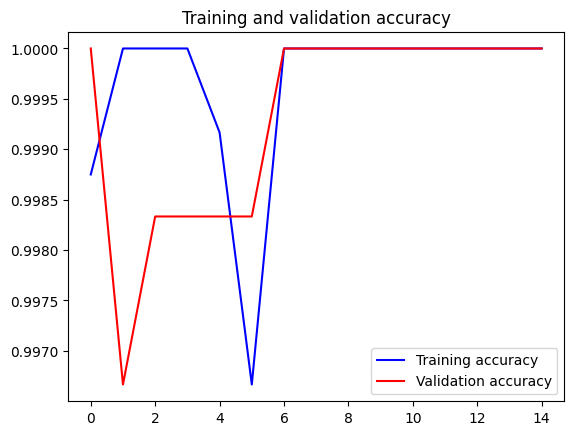

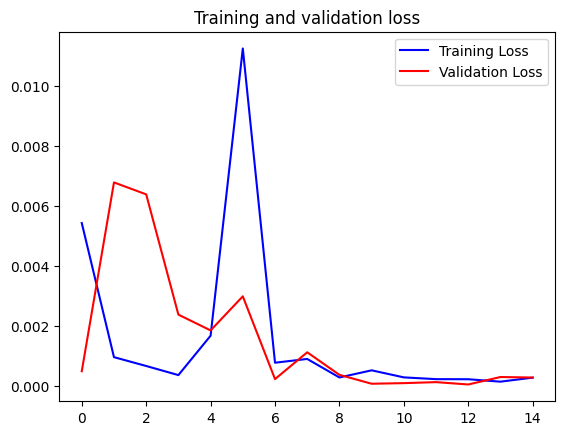

In [ ]:
import matplotlib.pyplot as plt

acc = history_v3.history['accuracy']
val_acc = history_v3.history['val_accuracy']
loss = history_v3.history['loss']
val_loss = history_v3.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
# Get the train accuracy
train_loss, train_accuracy = EfficientNetV2_model.evaluate(train_data, train_labels)
print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

# Get the val accuracy
val_loss, val_accuracy = EfficientNetV2_model.evaluate(val_data, val_labels)
print("Val Loss:", val_loss)
print("Val Accuracy:", val_accuracy)

75/75 [==============================] - 72s 957ms/step - loss: 6.8437e-06 - accuracy: 1.0000
Train Loss: 6.843722985649947e-06
Train Accuracy: 1.0
19/19 [==============================] - 17s 880ms/step - loss: 2.9078e-04 - accuracy: 1.0000
Val Loss: 0.000290783034870401
Val Accuracy: 1.0


In [ ]:
EfficientNetV2_model.save('EfficientNetV2_model.h5')
EfficientNetV2_model.save('EfficientNetV2_model')
!zip -r 'EfficientNetV2_model.zip' 'EfficientNetV2_model'

In [ ]:
import pathlib

converter = tf.lite.TFLiteConverter.from_saved_model('EfficientNetV2_model')

# Set the optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()

tflite_model_file = pathlib.Path('./EfficientNetV2_model.tflite')
tflite_model_file.write_bytes(tflite_model)

In [ ]:
import os

# Set the path to the test dataset folder
test_dataset_path = "/content/drive/MyDrive/dataset/Test"

# Load the test dataset
test_data = []
test_labels = []

# Iterate through the test dataset path and load the images
for category in os.listdir(test_dataset_path):
    category_path = os.path.join(test_dataset_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (150, 150))
        test_data.append(image)
        test_labels.append(category)

# Convert test_data and test_labels to numpy arrays
test_data = np.array(test_data)
test_labels = np.array(test_labels)

# Perform label encoding for test_labels
test_labels = label_encoder.transform(test_labels)

# Apply data normalization to test_data
test_data = test_data.astype('float32') / 255.0

# Create a dictionary to store the accuracy for each folder
folder_accuracy = {}

# Iterate over the folders in the test dataset
for folder in os.listdir(test_dataset_path):
    folder_path = os.path.join(test_dataset_path, folder)

    # Filter the test data and labels for the current folder
    folder_test_data = test_data[test_labels == label_encoder.transform([folder])[0]]
    folder_test_labels = test_labels[test_labels == label_encoder.transform([folder])[0]]

    # Evaluate the model on the current folder's test data
    folder_loss, folder_accuracy[folder] = EfficientNetV2_model.evaluate(folder_test_data, folder_test_labels, verbose=0)

# Print the accuracy for each folder
for folder, accuracy in folder_accuracy.items():
    print(f"Accuracy for folder {folder}: {accuracy}")

Accuracy for folder Grade 3: 1.0
Accuracy for folder Grade 2: 0.9399999976158142
Accuracy for folder Grade 1: 1.0


In [ ]:
# Get the test accuracy
test_loss, test_accuracy = EfficientNetV2_model.evaluate(test_data, test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
# Make predictions on the test data
test_predictions = EfficientNetV2_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Compare the predicted classes with the true classes
for i in range(len(test_labels)):
    print("True Label: ", label_encoder.inverse_transform([test_labels[i]]))
    print("Predicted Label: ", predicted_classes[i])
    print("------------------------------------")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Generate predictions on the test set
test_predictions = EfficientNetV2_model.predict(test_data)

# Convert the predicted probabilities to class labels
test_predicted_labels = np.argmax(test_predictions, axis=1)

# Create a confusion matrix
cm = confusion_matrix(test_labels, test_predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

10/10 [==============================] - 7s 725ms/step


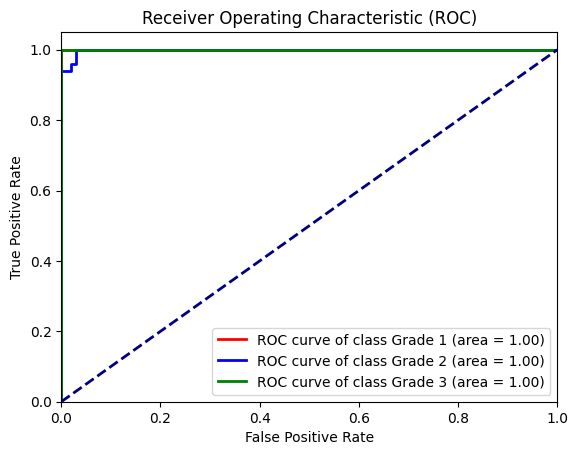

Macro-average ROC AUC: 0.9994666666666667


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
binary_labels = label_binarize(test_labels, classes=np.arange(len(class_names)))

# Compute the predicted probabilities for each class
class_probabilities = EfficientNetV2_model.predict(test_data)

# Compute the macro-average ROC AUC score
roc_auc = roc_auc_score(binary_labels, class_probabilities, average='macro')

# Plot the ROC curve for each class
plt.figure()
lw = 2
colors = ['red', 'blue', 'green']  # Add more colors if there are more classes
for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(binary_labels[:, i], class_probabilities[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc_class))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print the macro-average ROC AUC score
print("Macro-average ROC AUC:", roc_auc)

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test data
test_predictions = EfficientNetV2_model.predict(test_data)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)

# Decode the predicted labels using the label encoder
predicted_classes = label_encoder.inverse_transform(predicted_labels)

# Generate the classification report
report = classification_report(test_labels, predicted_labels, target_names=class_names)

# Print the classification report
print("Classification Report:")
print(report)

10/10 [==============================] - 8s 775ms/step
Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.94      1.00      0.97       100
     Grade 2       1.00      0.94      0.97       100
     Grade 3       1.00      1.00      1.00       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

